# Crystallisation process using crystal field models

In [62]:
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.colors import LinearSegmentedColormap

black_purple_yellow = LinearSegmentedColormap.from_list(
    "black_purple_yellow",
    [
        "black",      # low values
        "purple",     
        "yellow"      # high values 
    ],
    N=256
)

In [63]:
# Parameters of simulation

N_x = 140              # Size of grid
N_y = 140

L_x = 120
L_y = 120

M = 1.0
q_0 = 1.0
epsilon = 0.2

dx  = L_x/N_x  # time step and spatial mesh size
dy = L_y/N_y

dt = 0.01
time = 1200

Nt = int(round(time/dt))     # Number of time steps

phi = 0.05            # Initial condition of phi



N_visualize = 10000       # Number after which we want to visualize
print(Nt)


120000


In [64]:
# Spatial grid 
x = np.arange(N_x) * dx
y = np.arange(N_y) * dy
X, Y = np.meshgrid(x, y, indexing='ij')

# Add small fluctuation to initial condition

phi = phi + 0.05 * (2 * np.random.rand(N_x, N_y) - 1)



In [65]:
# Calculate wavevector k_m
k_x = 2.0 * np.pi * np.fft.fftfreq(N_x, d=dx)
k_y = 2.0 * np.pi * np.fft.fftfreq(N_y, d=dy)

K_x, K_y = np.meshgrid(k_x, k_y, indexing='ij')
k2 = K_x**2 + K_y**2


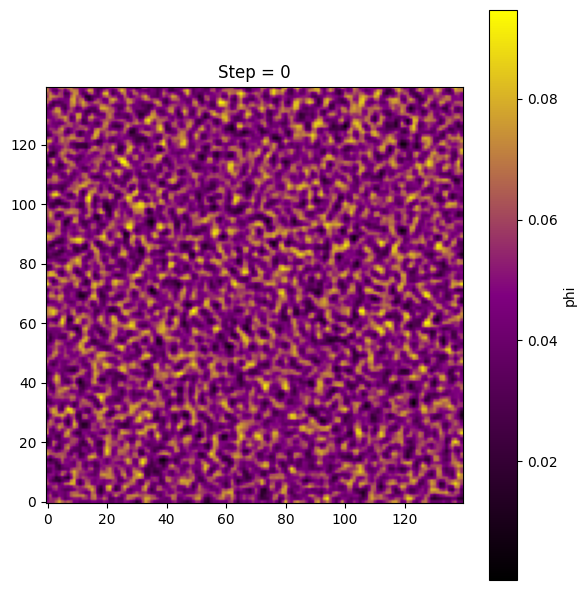

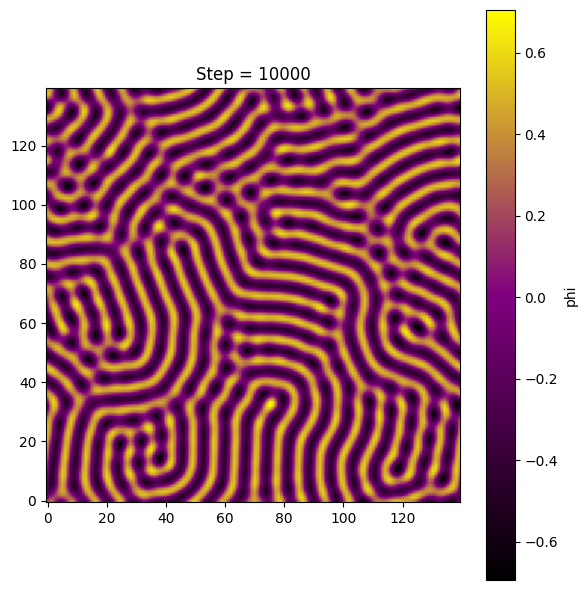

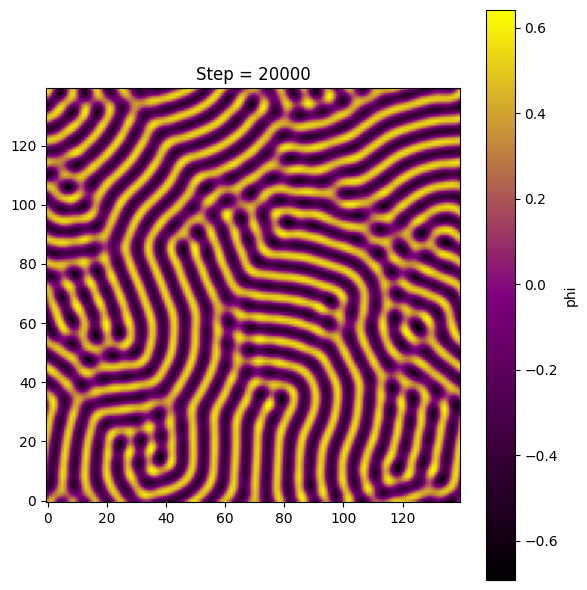

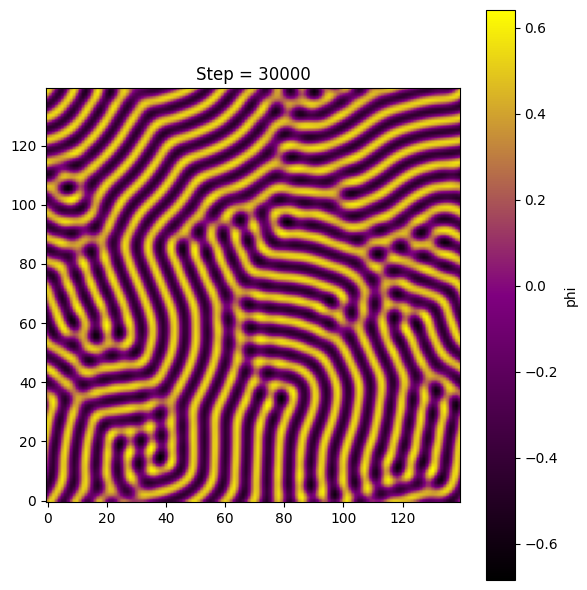

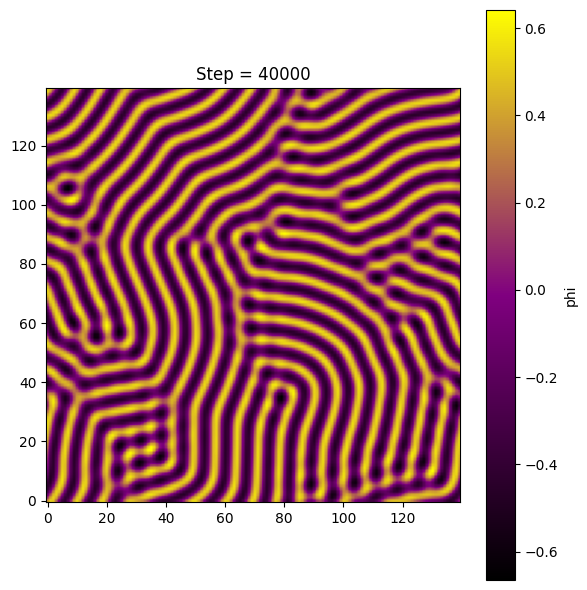

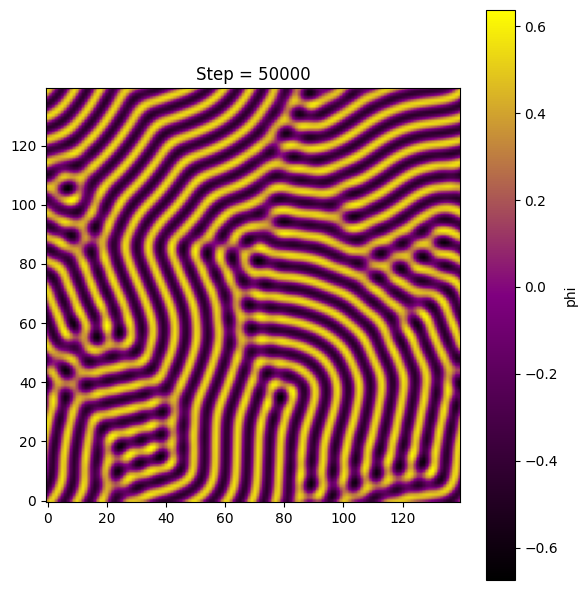

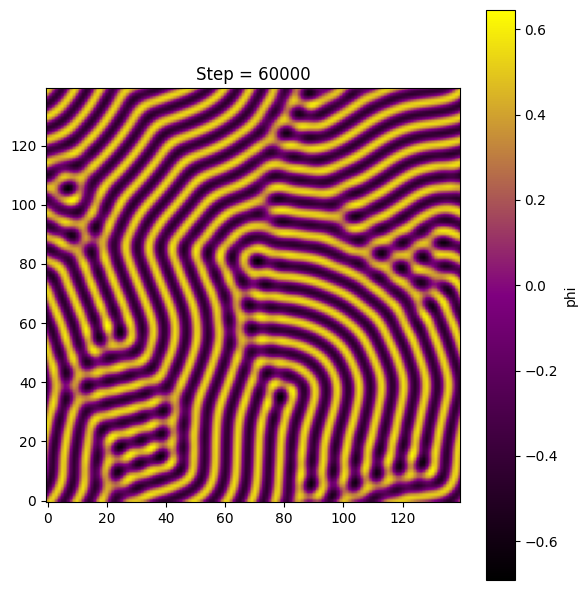

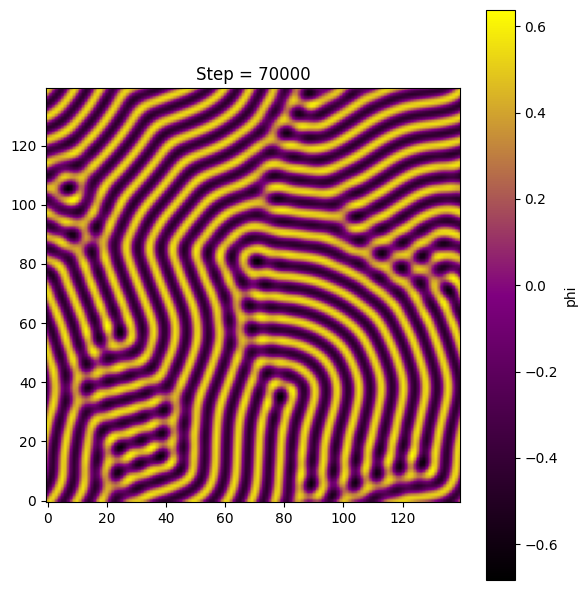

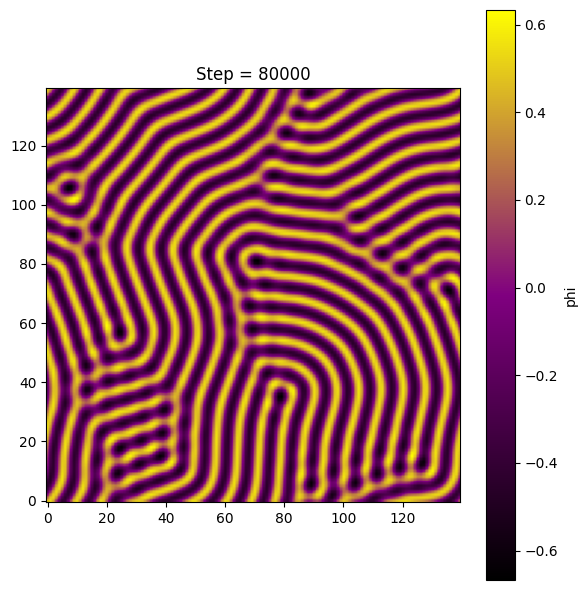

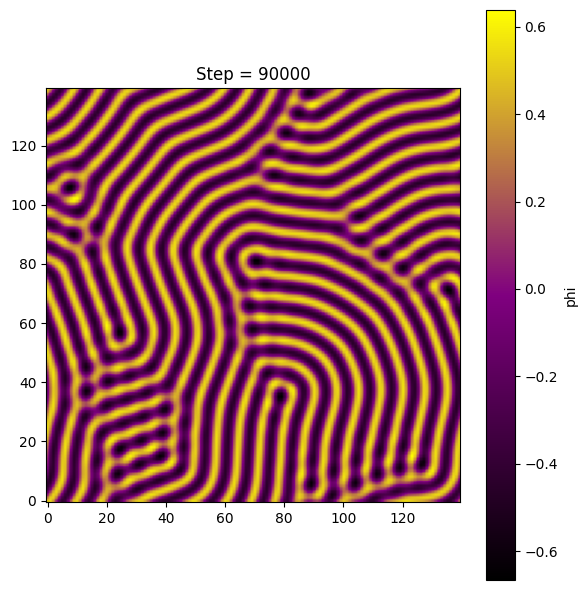

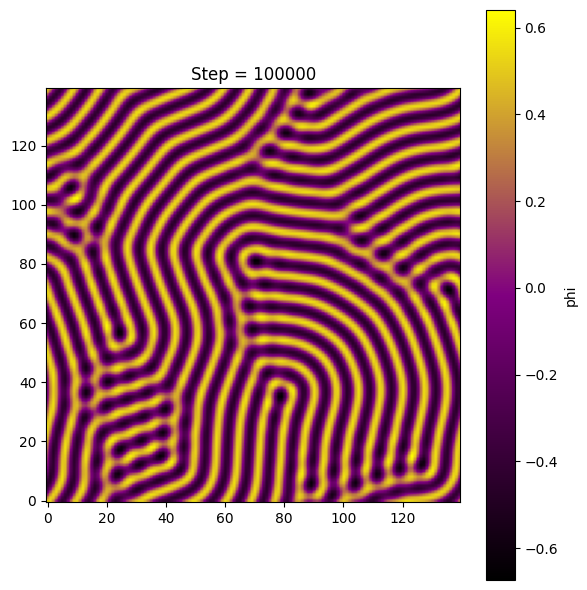

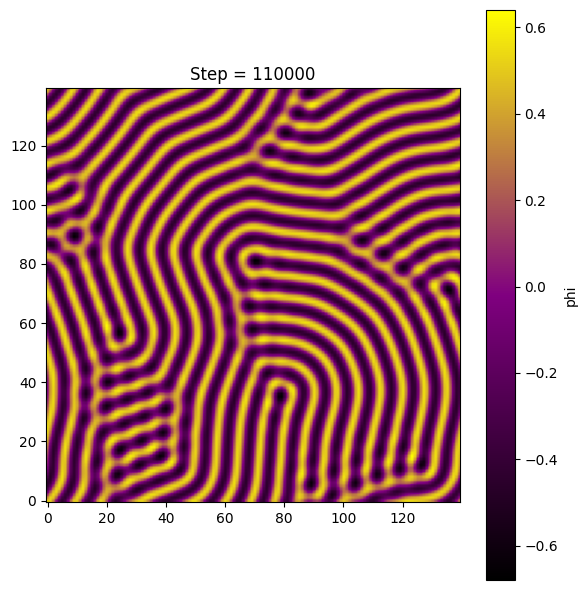

In [ ]:
# Time evolution of the system + visualization


for steps in range(Nt):
    # Perform Fourur trafo

    phi_hat = np.fft.fftn(phi)

    # Calculate the nonlinear term and fft back

    nonlinear = phi**3 
    nonlinear_hat = np.fft.fftn(nonlinear)

    # Calculate the next time step using iterative formula
    Lk = - k2 * (epsilon - (q_0**2 - k2)**2)

    num = phi_hat - dt * M * k2 * nonlinear_hat
    den = 1.0 + dt * M * Lk

    phi_hat_next = num / den

    # fft back into real space

    phi = np.real(np.fft.ifftn(phi_hat_next))

    # Visulaize for every N_visualize steps
    if steps % N_visualize == 0:
        plt.figure(figsize=(6,6))
        plt.imshow(
        phi,
        cmap=black_purple_yellow,
        origin='lower',
        vmin=np.min(phi),
        vmax=np.max(phi)
        )
        plt.colorbar(label="phi") 
        plt.title(f'Step = {steps}')
        plt.tight_layout()
        plt.show()
    


